### import lib

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns #to load real dataset
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error , r2_score

### Step 2 : Load Real Dataset (Seaborn MPG Dataset)

In [41]:
# this dataset is originally collected from real car data

df = sns.load_dataset("mpg") #miles per gallon
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


### Step 3 : Basic data cleaning

In [42]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [43]:
df.dropna(inplace=True)
df.isnull().sum()
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [44]:
# we will use 'horsepower' to predict 'mpg'
data = df[['horsepower','mpg']].dropna()
data.shape

(392, 2)

In [45]:
data

,horsepower,mpg
0,130.0,18.0
1,165.0,15.0
2,150.0,18.0
3,150.0,16.0
4,140.0,17.0
...,...,...
393,86.0,27.0
394,52.0,44.0
395,84.0,32.0
396,79.0,28.0


In [46]:
data.describe()

,horsepower,mpg
count,392.000000,392.000000
mean,104.469388,23.445918
std,38.491160,7.805007
min,46.000000,9.000000
25%,75.000000,17.000000
50%,93.500000,22.750000
75%,126.000000,29.000000
max,230.000000,46.600000


### Scatter plot visualization

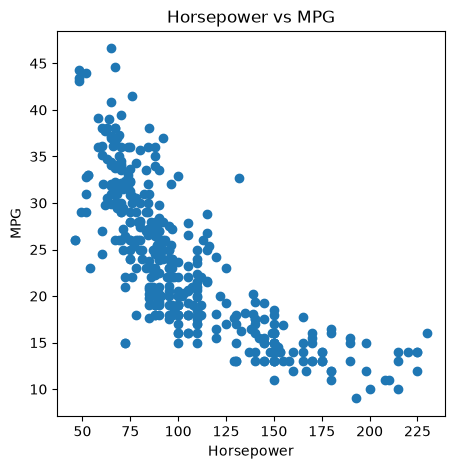

In [47]:
plt.figure(figsize=(5,5))
plt.scatter(data['horsepower'],data['mpg'])
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title("Horsepower vs MPG")
plt.show()

### Create and train the linear reg model

In [66]:
#Define feature and target

df_encoded = pd.get_dummies(df, columns=['origin'], drop_first=True)

x = df_encoded[['horsepower', 'weight', 'displacement', 'cylinders', 
                'acceleration', 'model_year', 'origin_japan', 'origin_usa']]
y = df_encoded['mpg']  #actual value

#split the data into training and test sets
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

#Create model
model = LinearRegression()

#Train model
model.fit(x_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[-0.02,-0.01, 0.02,..., 0.8 , 0.33,-2.88]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['horsepower','weight','displacement',...,'model_year','origin_japan', 'origin_usa']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-16.46
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [67]:
print(len(x_train))
print(len(y_train))
print(len(x_test))
print(len(y_test))

313
313
79
79


#### Visualize rhe best fit line

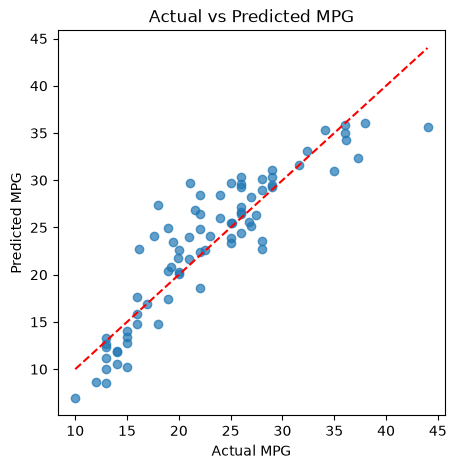

In [68]:
#predicted value
predicted_mpg = model.predict(x_test)

plt.figure(figsize=(5, 5))
# Actual vs Predicted scatter plot
plt.scatter(y_test, predicted_mpg, alpha=0.7)
# Perfect prediction line (45 degree line)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG")
plt.show()

#### Model Parameters (Slope and intercept)

In [69]:
#Slope
slope = model.coef_[0]
print("Slope: " , slope)

#intercept
intercept = model.intercept_
print("Intercept: " , intercept)

Slope:  -0.021620400404043182
Intercept:  -16.456430561780895


#### Cost function - MSE

In [70]:
mse = mean_squared_error (y_test,predicted_mpg)
print("MSE : ",mse)

MSE :  10.602279011688319


#### Gradient descent 

In [81]:
#sklearn automatically finds the best slope and inetercept
#using optimization technique(like gradient descent)
#example prediction

# [horsepower, weight, displacement, cylinders, acceleration, model_year]
sample_data = [[200, 3500, 300, 8, 12.0, 70,0,1]]

example_prediction = model.predict(sample_data)
print("Predicted MPG:", example_prediction[0])

Predicted MPG: 13.197287339321996


C:\Users\PRAKASH\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


#### Evaluation metrics (RMSE and R^2)

In [78]:
#RMSE

rmse = np.sqrt(mse)
print("RMSE : ",rmse)

#R2

r2 = r2_score(y_test,predicted_mpg)
print("R2 : ",r2)

RMSE :  3.256114096847394
R2 :  0.7922774714022591


#### Residual Analysis

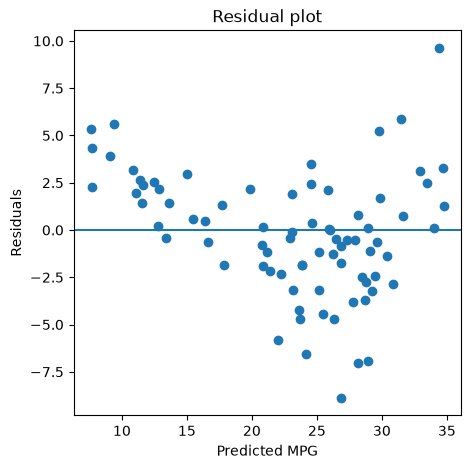

In [64]:
residuals = y_test - predicted_mpg

plt.figure(figsize=(5,5))
plt.scatter(predicted_mpg,residuals)
plt.axhline(y=0)
plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual plot")
plt.show()

## Handle Non-Linearity (Polynomial Regression) 

In [76]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(x_train)
X_test_poly = poly.transform(x_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)
print("Polynomial R2 Score:", r2_score(y_test, y_pred_poly))

Polynomial R2 Score: 0.8499726393135061


In [79]:
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

log_model = LinearRegression()
log_model.fit(x_train, y_train_log)

# Predict and transform back using np.exp
y_pred_log = np.exp(log_model.predict(x_test))
print("Log-Transformed R2 Score:", r2_score(y_test, y_pred_log))

Log-Transformed R2 Score: 0.8553975301601076


In [80]:
train_r2 = r2_score(y_train, poly_model.predict(X_train_poly))
test_r2 = r2_score(y_test, poly_model.predict(X_test_poly))

print("Train R2:", train_r2)
print("Test R2 :", test_r2)

Train R2: 0.8824235623462733
Test R2 : 0.8499726393135061
